# RenAIssance OCR Pipeline — Complete Project Showcase
---

## Digitising Early Modern Printed Spanish Documents with Deep Learning

This notebook provides a **comprehensive, end-to-end walkthrough** of the RenAIssance OCR pipeline.  
The goal: take scanned PDFs of 16th–17th-century Spanish printed books and produce **high-accuracy digital transcriptions** using a multi-stage AI pipeline.

### Pipeline Overview
```
PDFs → Page Images → YOLO Detection → Crop → Line Segmentation → Alignment → Augmentation → Split → Tesseract Baseline → TrOCR → Kraken CRNN → LLM Post-Correction
```

### Final Results (296 validation samples)

| Stage | CER ↓ | WER ↓ | chrF ↑ |
|---|---|---|---|
| Tesseract Baseline | 0.3553 | 0.7713 | 0.4850 |
| TrOCR Fine-tuned | 0.1750 | 0.4657 | 0.6507 |
| CRNN (Kraken) | 0.0928 | 0.3335 | 0.7837 |
| **CRNN + LLM Correction** | **0.0724** | **0.2363** | **0.8493** |

> **80% relative CER improvement** from Tesseract baseline to final pipeline.

---
## 1. Environment Setup & Imports

We import necessary libraries and key functions from each pipeline step.

In [35]:
import sys, os, json, csv, re, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from IPython.display import display, HTML, Markdown

# Visualisation settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})
warnings.filterwarnings('ignore')

ROOT = Path('.').resolve()
DATA = ROOT / 'Data'

print(f"Project root: {ROOT}")
print(f"Data folder:  {DATA}")

Project root: /home/hemanth/Documents/RenAIssance/Test1
Data folder:  /home/hemanth/Documents/RenAIssance/Test1/Data


In [36]:
# Try importing optional image libraries
try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    print("OpenCV not available — some image displays will be skipped.")

try:
    from PIL import Image as PILImage
    HAS_PIL = True
except ImportError:
    HAS_PIL = False

def show_image(path, title="", figsize=(10, 4)):
    """Display an image from a file path."""
    if not HAS_CV2:
        print(f"  [Cannot display: {path}]")
        return
    p = Path(path)
    if not p.exists():
        print(f"  [File not found: {p}]")
        return
    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    if img is None:
        print(f"  [Unreadable: {p}]")
        return
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    ax.set_title(title or p.name, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

print("✓ Helper functions loaded")

✓ Helper functions loaded


---
## 2. Phase 1 — PDF to Page Images  (`step1pdf_to_images.py`)

### What this step does
- Converts 6 historical Spanish PDF manuscripts into high-resolution PNG page images (300 DPI minimum)
- Each PDF becomes its own named subfolder under `Data/page_images/`
- Uses **PyMuPDF** for high-quality rasterisation

### Key Functions
```python
render_pdf_to_pngs(pdf_path, source_name, output_subdir, dpi)  # Renders all pages
list_pdfs(input_dir)                                             # Discovers PDF files
```

In [37]:
# Show the source PDFs
pdf_dir = ROOT / 'Handwritten'
if pdf_dir.exists():
    pdfs = sorted(pdf_dir.glob('*.pdf'))
    print(f"Source PDFs ({len(pdfs)} documents):\n")
    for i, p in enumerate(pdfs, 1):
        size_mb = p.stat().st_size / (1024 * 1024)
        print(f"  {i}. {p.name}  ({size_mb:.1f} MB)")
else:
    print("PDF directory not found")

Source PDFs (6 documents):

  1. Buendia - Instruccion.pdf  (18.1 MB)
  2. Covarrubias - Tesoro lengua.pdf  (106.6 MB)
  3. Guardiola - Tratado nobleza.pdf  (69.2 MB)
  4. PORCONES.228.38 – 1646.pdf  (45.4 MB)
  5. PORCONES.23.5 - 1628.pdf  (30.5 MB)
  6. PORCONES.748.6 – 1650.pdf  (54.6 MB)


Page images generated for 6 sources:

  source1: 33 pages
  source2: 990 pages
  source3: 311 pages
  source4: 23 pages
  source5: 12 pages
  source6: 26 pages

  Total: 1395 page images


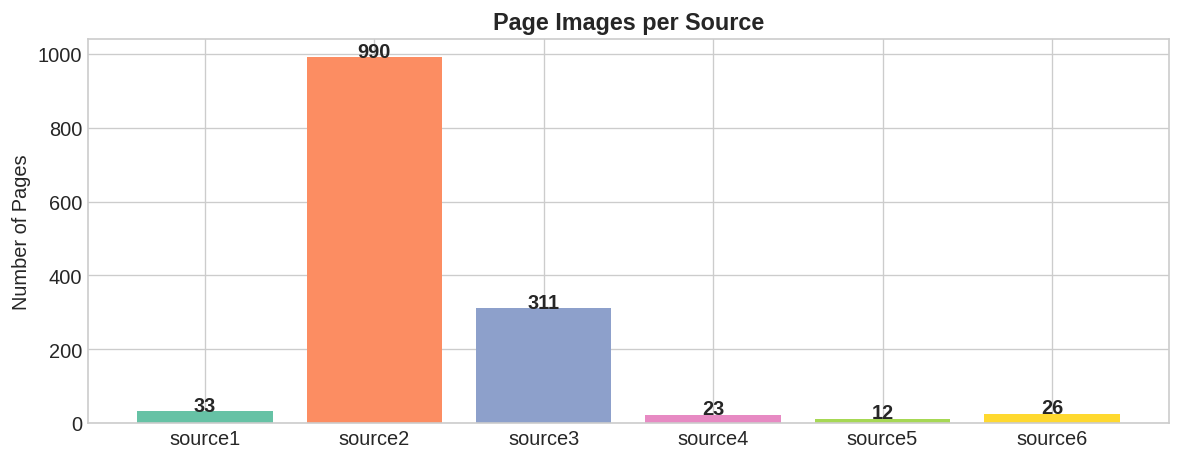

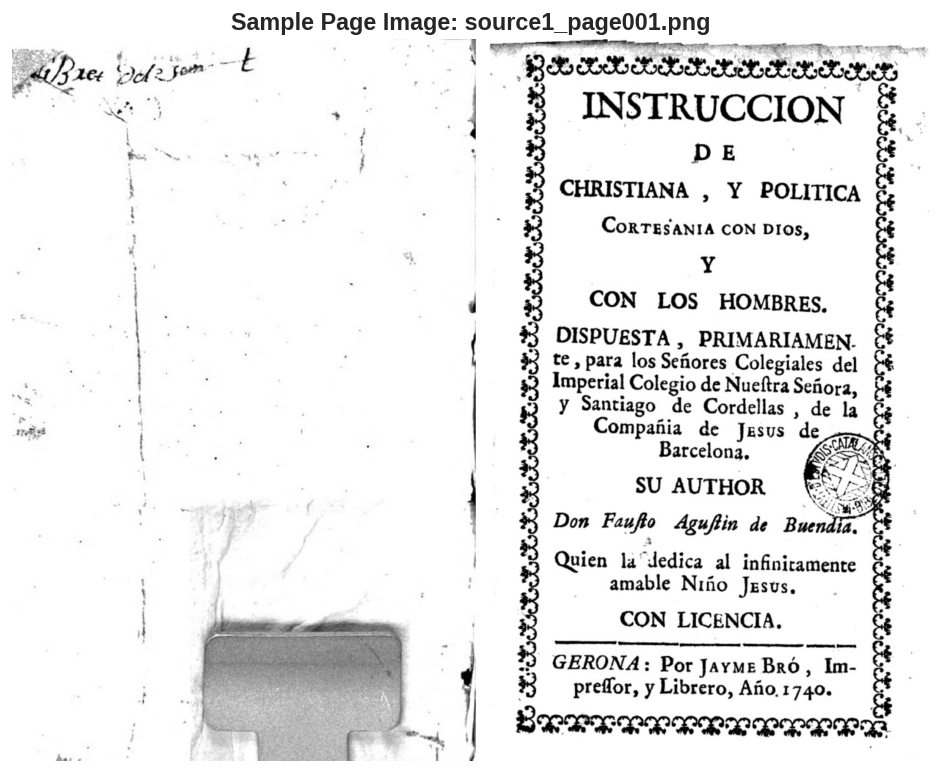

In [38]:
# Show generated page images
page_dir = DATA / 'page_images'
if page_dir.exists():
    sources = sorted([d for d in page_dir.iterdir() if d.is_dir()])
    print(f"Page images generated for {len(sources)} sources:\n")
    total = 0
    src_data = []
    for s in sources:
        pages = list(s.glob('*.png'))
        total += len(pages)
        src_data.append({'Source': s.name, 'Pages': len(pages)})
        print(f"  {s.name}: {len(pages)} pages")
    print(f"\n  Total: {total} page images")
    
    # Bar chart
    df_src = pd.DataFrame(src_data)
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(df_src['Source'], df_src['Pages'], color=plt.cm.Set2.colors[:len(df_src)])
    ax.set_title('Page Images per Source', fontweight='bold')
    ax.set_ylabel('Number of Pages')
    for bar, val in zip(bars, df_src['Pages']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
                ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Show a sample page image
    sample = sorted(sources[0].glob('*.png'))[0] if sources else None
    if sample:
        show_image(sample, f"Sample Page Image: {sample.name}", figsize=(8, 10))
else:
    print("Page images directory not found. Run step1pdf_to_images.py first.")

---
## 3. Phase 2 — YOLO Main-Text Detection (`step2_yolo_pipeline.py` + `step3_yolo_crop.py`)

### What this step does
1. **Annotation & Export**: Pages annotated in Label Studio with `main_text` bounding boxes, exported in YOLO format  
2. **Stratified Split**: 80/20 train/val split ensuring all 6 sources and both single/multi-column pages appear in both splits  
3. **Fine-tune YOLOv8n**: Nano variant, pretrained on COCO, fine-tuned for 1-class detection (`maintext`)
4. **Inference + Crop**: Run on all pages → crop detected text regions

### Key Functions
```python
stratified_split(labelled_dir, train_ratio, seed)        # Source-aware split
create_yolo_dataset(labelled_dir, output_dir, ...)       # Build YOLO dataset
train_yolo(data_yaml)                                     # Fine-tune YOLOv8n
evaluate_yolo(data_yaml)                                  # Compute mAP, P, R
run_yolo_on_all_pages()                                   # Full-dataset inference
crop_main_text_regions(manifest)                          # Crop detected regions
```

### Training Configuration
| Parameter | Value | Rationale |
|---|---|---|
| Model | YOLOv8n | Lightweight, sufficient for 1-class |
| Epochs | 100 (early stop patience=15) | Prevent overfitting |
| Batch size | 4 | 4GB VRAM (RTX 3050 Ti) |
| Image size | 480px | Memory-efficient |
| Augmentation | Minimal (no mosaic/flip) | Documents shouldn't flip |

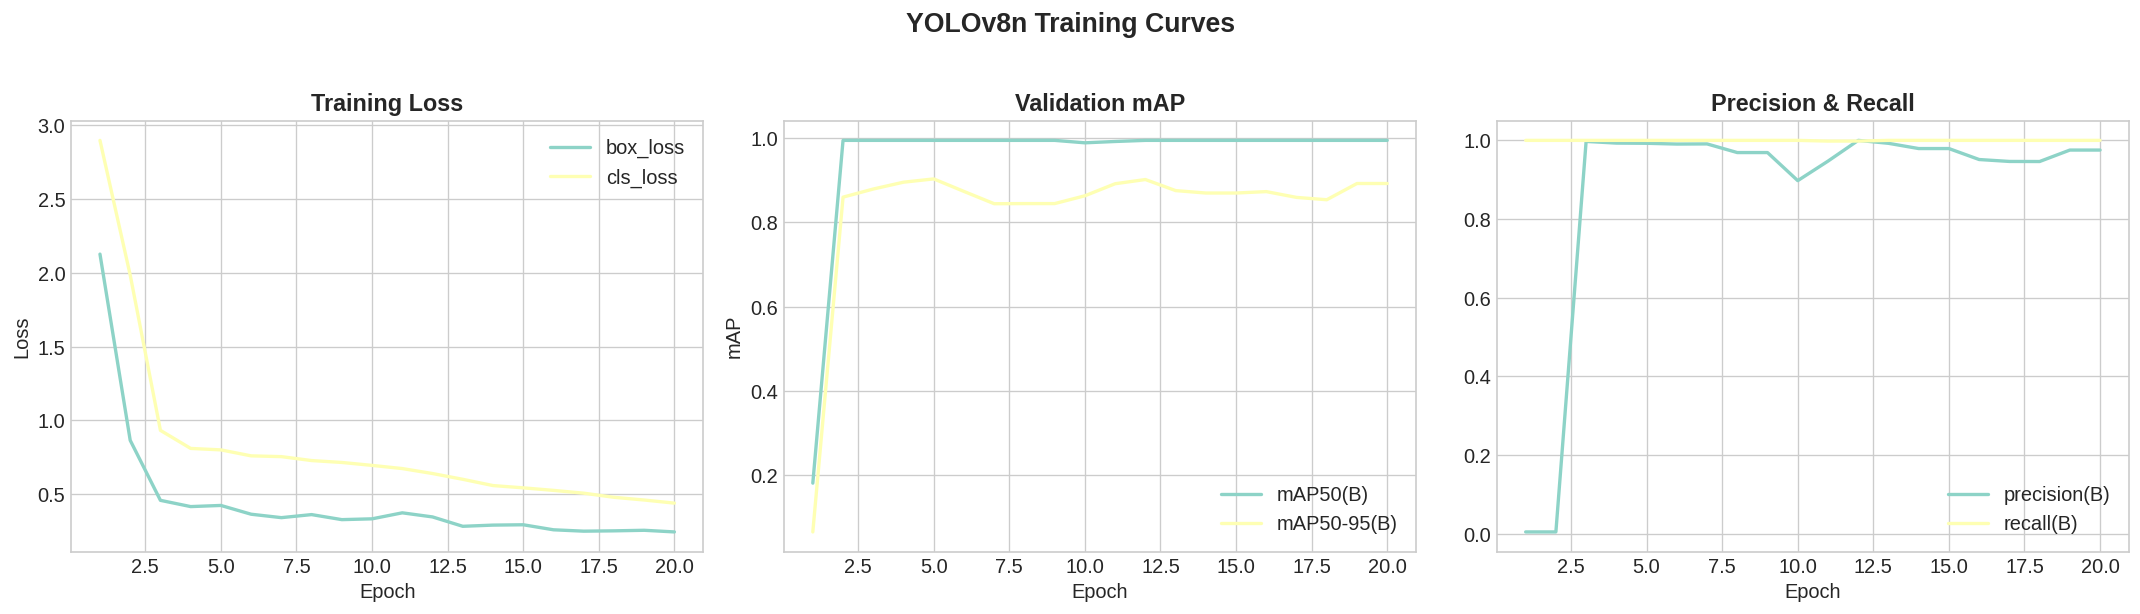

In [39]:
# Load YOLO training metrics if available
yolo_results_csv = ROOT / 'runs' / 'yolo_maintext' / 'results.csv'
if yolo_results_csv.exists():
    df_yolo = pd.read_csv(yolo_results_csv)
    df_yolo.columns = [c.strip() for c in df_yolo.columns]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Training loss
    loss_cols = [c for c in df_yolo.columns if 'train/box_loss' in c or 'train/cls_loss' in c]
    if loss_cols:
        for c in loss_cols:
            axes[0].plot(df_yolo['epoch'], df_yolo[c], label=c.split('/')[-1], linewidth=2)
        axes[0].set_title('Training Loss', fontweight='bold')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
    
    # mAP
    map_cols = [c for c in df_yolo.columns if 'metrics/mAP' in c]
    if map_cols:
        for c in map_cols:
            axes[1].plot(df_yolo['epoch'], df_yolo[c], label=c.split('/')[-1], linewidth=2)
        axes[1].set_title('Validation mAP', fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('mAP')
        axes[1].legend()
    
    # Precision & Recall
    pr_cols = [c for c in df_yolo.columns if 'precision' in c.lower() or 'recall' in c.lower()]
    if pr_cols:
        for c in pr_cols:
            axes[2].plot(df_yolo['epoch'], df_yolo[c], label=c.split('/')[-1], linewidth=2)
        axes[2].set_title('Precision & Recall', fontweight='bold')
        axes[2].set_xlabel('Epoch')
        axes[2].legend()
    
    plt.suptitle('YOLOv8n Training Curves', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("⚠ YOLO results.csv not found. Training curves unavailable.")
    print("  Expected at:", yolo_results_csv)

YOLO Crop Statistics

  Total crops created:     2403
  Pages with no detection: 35
  Padding (px):            5

  Crops per source:
    source1: 61
    source2: 1950
    source3: 298
    source4: 32
    source5: 23
    source6: 39


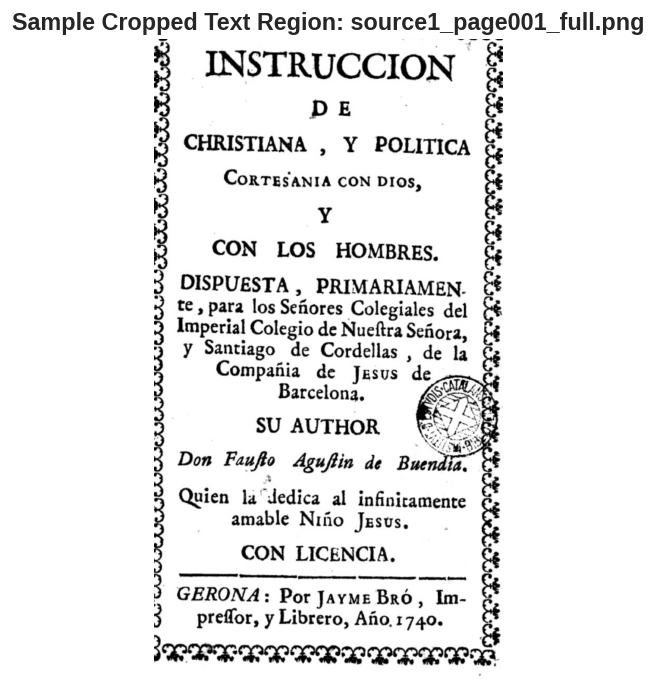

In [40]:
# Show crop statistics
crop_manifest_path = DATA / 'crop_manifest.json'
if crop_manifest_path.exists():
    with open(crop_manifest_path) as f:
        crop_manifest = json.load(f)
    
    print("YOLO Crop Statistics\n")
    print(f"  Total crops created:     {crop_manifest.get('total_crops', 'N/A')}")
    print(f"  Pages with no detection: {crop_manifest.get('skipped_pages_no_detection', 'N/A')}")
    print(f"  Padding (px):            {crop_manifest.get('pad_px', 'N/A')}")
    print(f"\n  Crops per source:")
    
    cps = crop_manifest.get('crops_per_source', {})
    for src, cnt in sorted(cps.items()):
        print(f"    {src}: {cnt}")
    
    # Show a sample crop
    crops_dir = DATA / 'cropped_main_text'
    if crops_dir.exists():
        sample_sources = sorted([d for d in crops_dir.iterdir() if d.is_dir()])
        if sample_sources:
            samples = sorted(sample_sources[0].glob('*.png'))[:1]
            for s in samples:
                show_image(s, f"Sample Cropped Text Region: {s.name}", figsize=(12, 6))
else:
    print("Crop manifest not found.")

---
## 4. Phase 3 — Line Segmentation (`step5_line_segmentation.py`)

### What this step does
Per cropped text region:
1. **Deskew** — projection-profile variance maximisation (two-pass: coarse 0.5° + fine 0.1°)
2. **Denoise / Remove Bleed-Through** — median filter + morphological background normalisation
3. **Binarize** — Sauvola adaptive thresholding (handles uneven illumination)
4. **Seam-Carving Line Segmentation** — constrained DP between projection valleys, energy = ink density + distance transform
5. **Crop** individual line strip images with white-padded seam boundaries

### Why Seam Carving?
Historical scans have **curved baselines** and **bleed-through** where simple horizontal cuts fail.  
Seam carving traces the natural boundary between lines using dynamic programming.

### Key Functions
```python
estimate_skew_angle(gray)              # Two-pass angle estimation
deskew(gray)                           # Deskew using skimage rotation
denoise_and_remove_bleed(gray)         # Median + morphological normalisation
binarize(gray, window_size, k)         # Sauvola thresholding
segment_lines(binary)                  # Seam-carving line detection
crop_line(image, region, pad_y)        # Seam-bounded line extraction
compute_ink_ratio(line_img)            # Dark-pixel ratio for filtering
parse_transcript(docx_path)            # .docx → ordered text lines
preprocess_and_segment(image_path, output_dir, ...)  # Full per-image pipeline
```

Line Segmentation Results (6 sources)

  Buendia - Instruccion transcription: 107 line crops
  Covarrubias - Tesoro lengua transcription: 129 line crops
  Guardiola - Tratado nobleza transcription: 79 line crops
  PORCONES.228.38 – 1646: 163 line crops
  PORCONES.23.5 - 1628: 190 line crops
  PORCONES.748.6 – 1650: 130 line crops

  Total line crops: 798


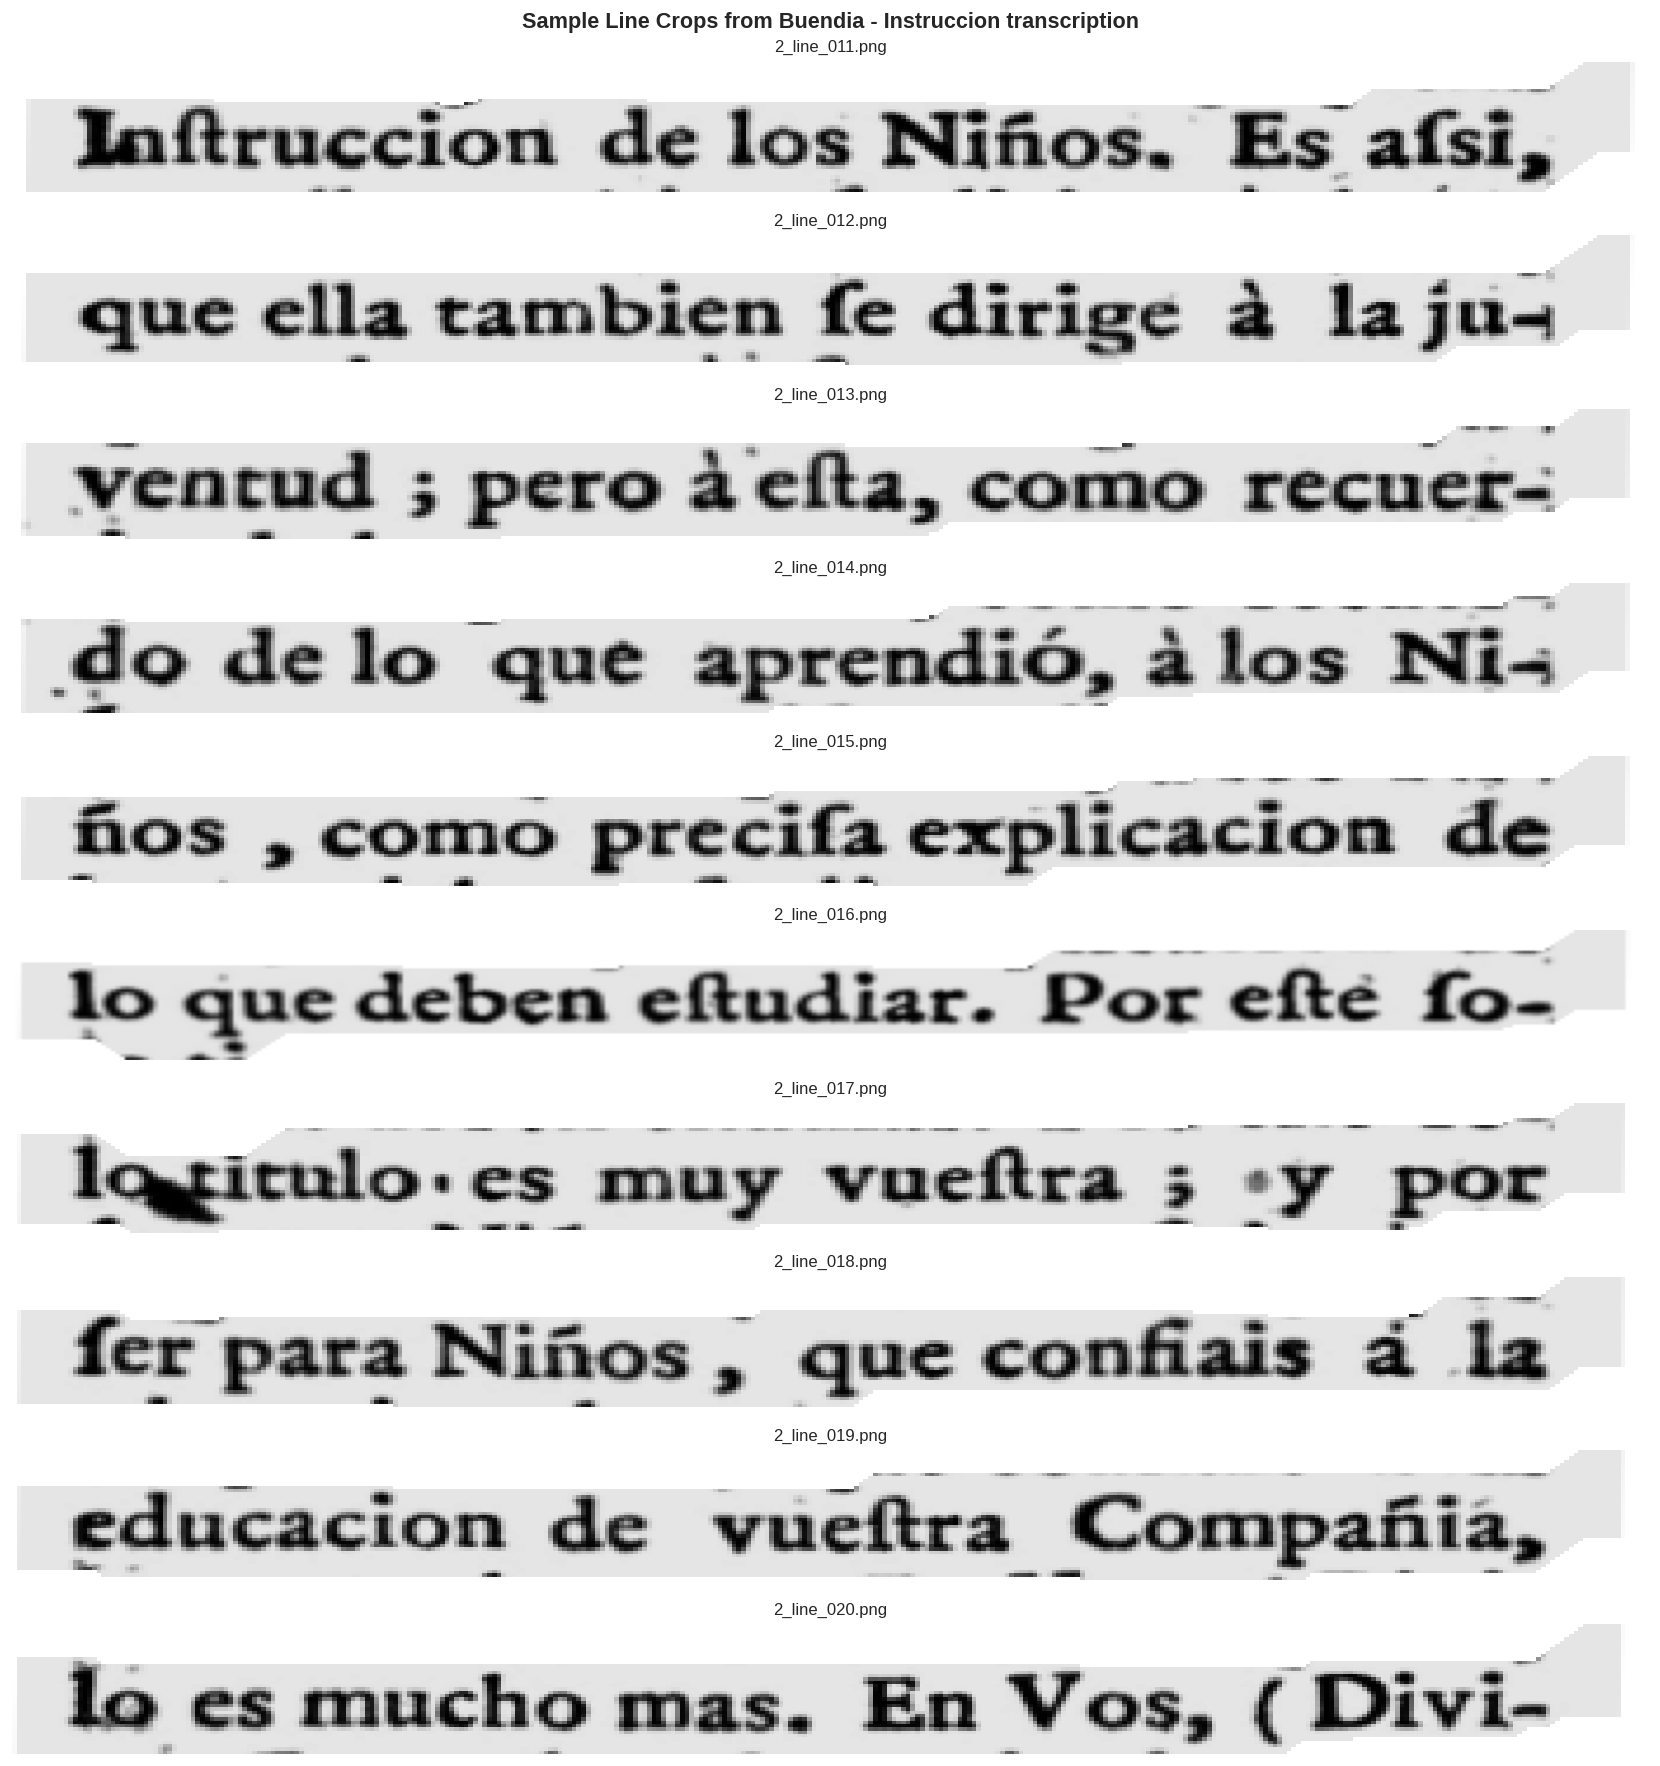

In [41]:
# Show line crops and segmentation stats
line_crops_dir = DATA / 'line_crops'
if line_crops_dir.exists():
    source_dirs = sorted([d for d in line_crops_dir.iterdir() if d.is_dir()])
    print(f"Line Segmentation Results ({len(source_dirs)} sources)\n")
    
    lc_data = []
    for sd in source_dirs:
        lines = list(sd.glob('*.png'))
        lc_data.append({'Source': sd.name[:30], 'Lines': len(lines)})
        print(f"  {sd.name}: {len(lines)} line crops")
    
    total_lines = sum(d['Lines'] for d in lc_data)
    print(f"\n  Total line crops: {total_lines}")
    
    # Show sample line crops from first source
    if source_dirs:
        sample_lines = sorted(source_dirs[0].glob('*.png'))[10:20]
        if sample_lines:
            fig, axes = plt.subplots(len(sample_lines), 1, figsize=(14, len(sample_lines)*1.5))
            if len(sample_lines) == 1:
                axes = [axes]
            for ax, lp in zip(axes, sample_lines):
                if HAS_CV2:
                    img = cv2.imread(str(lp), cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        ax.imshow(img, cmap='gray', aspect='auto')
                ax.set_title(lp.name, fontsize=10)
                ax.axis('off')
            plt.suptitle(f'Sample Line Crops from {source_dirs[0].name}',
                        fontweight='bold', fontsize=13)
            plt.tight_layout()
            plt.show()
else:
    print("Line crops directory not found.")

---
## 5. Phase 4 — Ground Truth Alignment (`step4_rename_and_realign_txt.py`)

### What this step does
- Parse transcripts (`.txt` / `.docx`) into ordered text lines
- Align line crop images with transcript lines **sequentially** (reading order)
- Handle multi-column pages (left column before right)
- Output a unified CSV: `source, page, line, image_path, ground_truth_text`

### Alignment Strategy
```
Line crop 001  →  "Al"
Line crop 002  →  "INFINITAMENTE AMABLE"
Line crop 003  →  "NIÑO JESUS."
...
```

---
## 6. Phase 5 & 6 — Augmentation & Source-Level Split (`step6_augmentation_split.py`)

### Split Strategy
- **Source-level split** (not line-level) — tests real generalisation to unseen books
- 4 sources → Training, 2 sources → Validation

### Augmentations Applied (training only)
| Augmentation | Why |
|---|---|
| Rotation ±2° | Simulates tilted scanning |
| Gaussian blur | Simulates focus issues |
| Brightness ±12 | Simulates ink fading |
| Gaussian noise σ∈[2,8] | Simulates paper texture |
| Elastic distortion | Simulates paper warping |

### Key Functions
```python
apply_rotation(img, rng)       apply_blur(img, rng)
apply_brightness(img, rng)     apply_noise(img, rng)
apply_elastic(img, rng)        augment_image(img_gray, rng)
pick_val_sources(...)          read_alignment_rows(csv)
```

📊 Train/Val Split Statistics

  Train sources: ['source2', 'source3', 'source4', 'source6']
  Val sources:   ['source1', 'source5']
  Augmentations per image: 5

  Train rows (augmented): 2385
  Val rows (pristine):    296
  Total rows:             2681


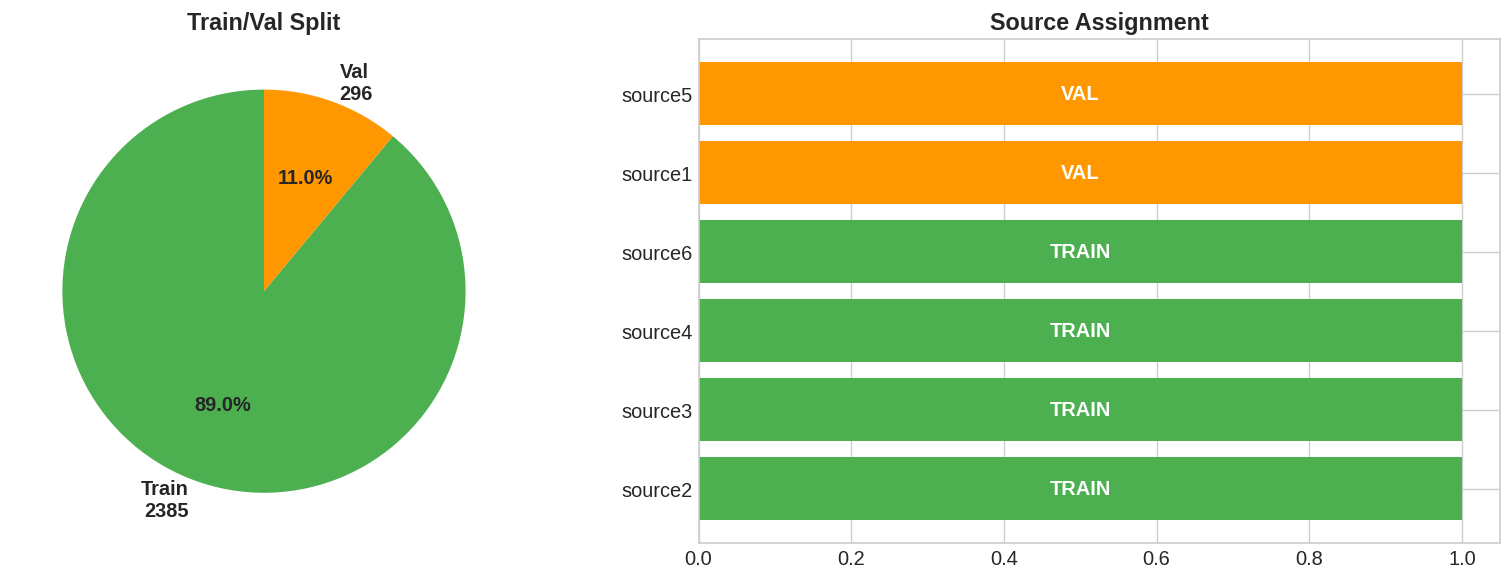

In [42]:
# Display split statistics
split_stats_path = DATA / 'ocr_dataset' / 'split_stats.json'
if split_stats_path.exists():
    with open(split_stats_path) as f:
        sstats = json.load(f)
    
    print("📊 Train/Val Split Statistics\n")
    print(f"  Train sources: {sstats['train_source_ids']}")
    print(f"  Val sources:   {sstats['val_source_ids']}")
    print(f"  Augmentations per image: {sstats['aug_per_image']}")
    print(f"\n  Train rows (augmented): {sstats['train_rows']}")
    print(f"  Val rows (pristine):    {sstats['val_rows']}")
    print(f"  Total rows:             {sstats['full_rows']}")
    
    # Pie chart
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].pie([sstats['train_rows'], sstats['val_rows']],
                labels=[f"Train\n{sstats['train_rows']}", f"Val\n{sstats['val_rows']}"],
                colors=['#4CAF50', '#FF9800'], autopct='%1.1f%%',
                startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
    axes[0].set_title('Train/Val Split', fontweight='bold')
    
    # Source distribution
    src_labels = sstats['train_source_ids'] + sstats['val_source_ids']
    src_colors = ['#4CAF50']*len(sstats['train_source_ids']) + ['#FF9800']*len(sstats['val_source_ids'])
    axes[1].barh(src_labels, [1]*len(src_labels), color=src_colors)
    axes[1].set_title('Source Assignment', fontweight='bold')
    axes[1].set_xlabel('')
    for i, sid in enumerate(src_labels):
        label = 'TRAIN' if sid in sstats['train_source_ids'] else 'VAL'
        axes[1].text(0.5, i, label, ha='center', va='center', fontweight='bold', fontsize=12, color='white')
    
    plt.tight_layout()
    plt.show()
else:
    print("Split stats not found.")

---
## 7. Phase 7 — Tesseract Baseline (`step7_tesseract_baseline.py`)

### What this step does
- Run **out-of-the-box Tesseract** (Spanish, PSM 6) on validation line images
- Compute CER, WER, chrF — this is the **floor** we must beat

### Why Tesseract?
Tesseract provides a strong, reproducible baseline. It has no knowledge of early modern Spanish or historical fonts, so any improvement by our fine-tuned models demonstrates genuine learning.

### Key Functions
```python
run_tesseract(image_path, lang, psm, oem)   # Single-image OCR
levenshtein_distance(seq_a, seq_b)           # Edit distance
cer_stats(ref, hyp)                          # Character Error Rate
wer_stats(ref, hyp)                          # Word Error Rate
chrf_corpus(refs, hyps)                      # Character n-gram F-score
aggregate_metrics(rows)                      # Corpus-level metrics
```

---
## 8. Phase 8 — TrOCR Fine-tuning (`step8_trocr_finetune.py`)

### What this step does
- Fine-tune **microsoft/trocr-base-printed** (Vision Encoder-Decoder) on our aligned pairs
- Frozen encoder (only decoder trained) — critical for ≤4 GB VRAM
- fp16 mixed precision + gradient checkpointing + 8-bit AdamW
- Early stopping on validation CER

### Architecture
```
[Line Image] → ViT Encoder (frozen) → Cross-Attention → GPT-2 Decoder → [Text]
```

### Memory Optimisations for 4GB VRAM
| Technique | VRAM Saved |
|---|---|
| Freeze encoder | ~60% parameters |
| fp16 mixed precision | ~50% activations |
| Gradient checkpointing | ~40% activations |
| 8-bit AdamW | ~50% optimizer states |
| batch_size=1 + grad_accum=8 | Peak VRAM minimised |

---
## 9. Phase 9 — Kraken CRNN (`step9.0–9.2`)

### Three sub-steps
1. **Prepare Data** (`step9.0`): Convert manifests to Kraken ground-truth format (image + `.gt.txt` pairs)
2. **Compile** (`step9.1`): Compile into binary Arrow datasets using `ketos compile`
3. **Train** (`step9.2`): Train CRNN with cosine schedule, augmentation, auto batch-size fallback

### Why CRNN alongside TrOCR?
- **Different architecture** → different error patterns → complementary strengths  
- CRNNs are faster at inference and can handle variable-width inputs natively  
- Kraken is purpose-built for historical document OCR

---
## 10. Phase 10 — LLM Post-Correction (`step10_Post_LLM_correction.py`)

### What this step does
- Send raw CRNN output to **Gemini 2.5 Flash** in JSON chunks
- Strict prompt: fix **only** character-level OCR errors, NO modernisation, NO hallucination
- Preserve archaic spellings, hyphens, punctuation exactly

### Prompt Design Highlights
- ❌ No accent modernisation (except ñ)
- ❌ No word completion across lines
- ✅ Fix f/s, I/l, rn/m confusions
- ✅ ç → z, expand q → que
- Temperature = 0.0 for deterministic output

---
## 11. Final Results & Comprehensive Analysis

Let's load the actual evaluation data and create detailed visualisations.

In [43]:
# Load the final LLM-corrected results
llm_csv = ROOT / 'llm_corrected_results_final.csv'
kraken_csv = ROOT / 'kraken_eval_results.csv'

if llm_csv.exists():
    df_final = pd.read_csv(llm_csv)
    print(f"✓ Loaded LLM-corrected results: {len(df_final)} samples")
    print(f"  Columns: {list(df_final.columns)}")
    display(df_final.head(3))
else:
    print("⚠ LLM results file not found")
    df_final = None

if kraken_csv.exists():
    df_kraken = pd.read_csv(kraken_csv)
    print(f"\n✓ Loaded Kraken eval results: {len(df_kraken)} samples")
else:
    df_kraken = None

✓ Loaded LLM-corrected results: 296 samples
  Columns: ['image_path', 'ground_truth_text', 'crnn_prediction', 'cer_per_line', 'llm_correction', 'cer_before', 'cer_after', 'wer_before', 'wer_after', 'chrf_before', 'chrf_after']


,image_path,ground_truth_text,crnn_prediction,cer_per_line,llm_correction,cer_before,cer_after,wer_before,wer_after,chrf_before,chrf_after
0,/home/hemanth/Documents/RenAIssance/Test1/Data...,﻿Al,AR,0.500000,Al,0.666667,0.666667,1.0,1.0,0.057471,0.057471
1,/home/hemanth/Documents/RenAIssance/Test1/Data...,INFINITAMENTE AMABLE,NEINTTAMRNTE AMAE,0.300000,ATENTAMENTE AMADO,0.300000,0.400000,1.0,1.0,0.316695,0.474702
2,/home/hemanth/Documents/RenAIssance/Test1/Data...,NIÑO JESUS.,NNO B,0.727273,NNO B,0.727273,0.727273,1.0,1.0,0.035461,0.035461



✓ Loaded Kraken eval results: 296 samples


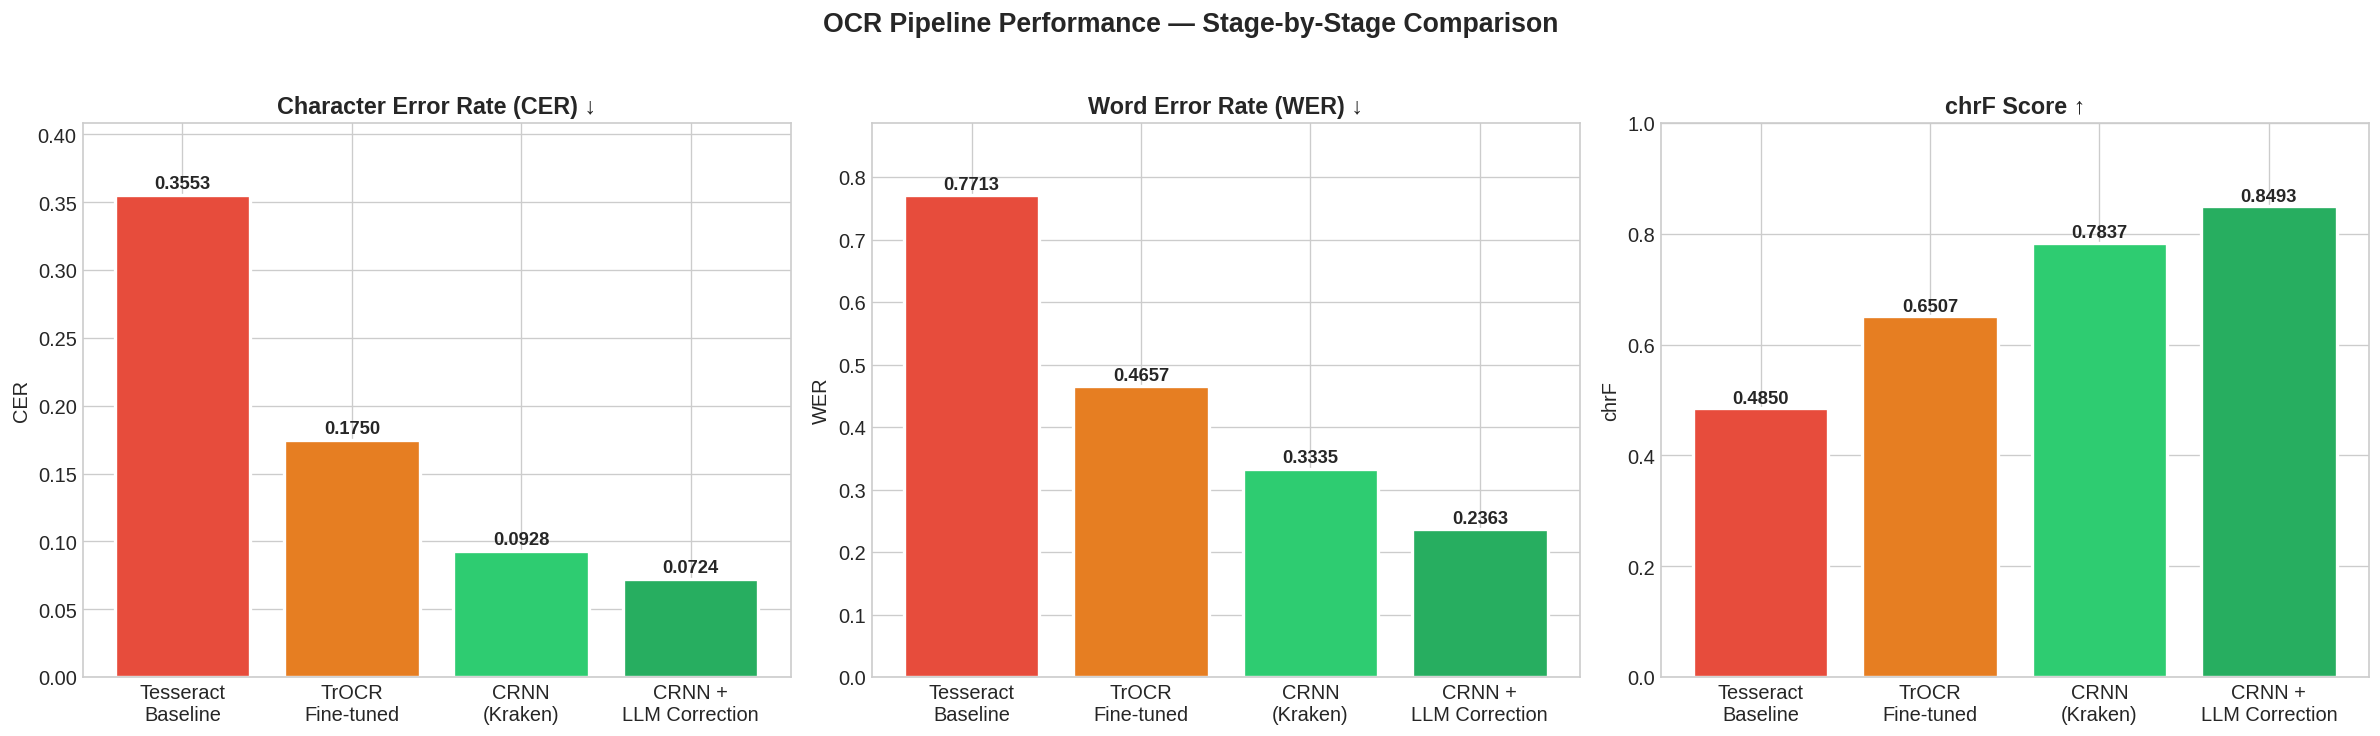

In [44]:
# ═══════════════════════════════════════════════
# METRICS COMPARISON — BAR CHARTS
# ═══════════════════════════════════════════════

stages = ['Tesseract\nBaseline', 'TrOCR\nFine-tuned', 'CRNN\n(Kraken)', 'CRNN +\nLLM Correction']
cer_vals = [0.3553, 0.1750, 0.0928, 0.0724]
wer_vals = [0.7713, 0.4657, 0.3335, 0.2363]
chrf_vals = [0.4850, 0.6507, 0.7837, 0.8493]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']

# CER
bars = axes[0].bar(stages, cer_vals, color=colors, edgecolor='white', linewidth=2)
axes[0].set_title('Character Error Rate (CER) ↓', fontweight='bold', fontsize=14)
axes[0].set_ylabel('CER')
for bar, val in zip(bars, cer_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, max(cer_vals) * 1.15)

# WER
bars = axes[1].bar(stages, wer_vals, color=colors, edgecolor='white', linewidth=2)
axes[1].set_title('Word Error Rate (WER) ↓', fontweight='bold', fontsize=14)
axes[1].set_ylabel('WER')
for bar, val in zip(bars, wer_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, max(wer_vals) * 1.15)

# chrF
bars = axes[2].bar(stages, chrf_vals, color=colors, edgecolor='white', linewidth=2)
axes[2].set_title('chrF Score ↑', fontweight='bold', fontsize=14)
axes[2].set_ylabel('chrF')
for bar, val in zip(bars, chrf_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[2].set_ylim(0, 1.0)

plt.suptitle('OCR Pipeline Performance — Stage-by-Stage Comparison',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

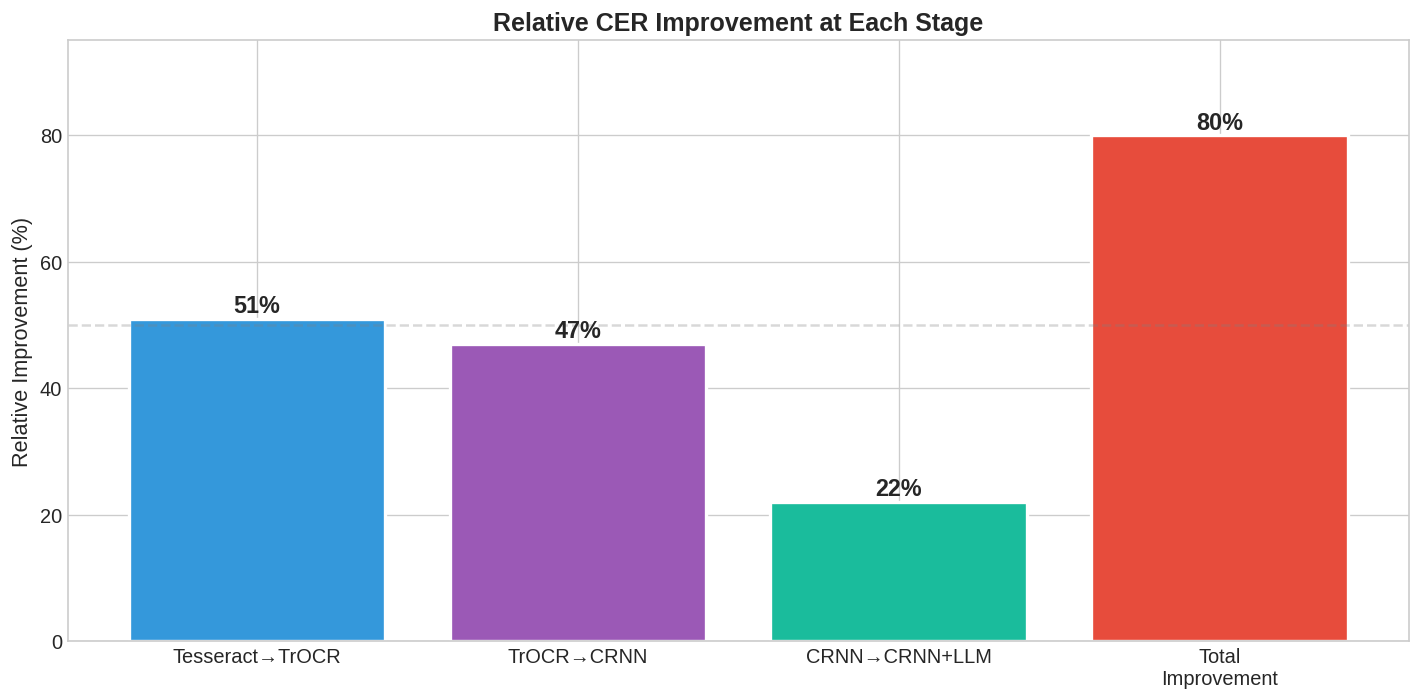

In [45]:
# ═══════════════════════════════════════════════
# RELATIVE IMPROVEMENT WATERFALL
# ═══════════════════════════════════════════════

transitions = ['Tesseract→TrOCR', 'TrOCR→CRNN', 'CRNN→CRNN+LLM', 'Total\nImprovement']
cer_improvements = [51, 47, 22, 80]  # percentage relative improvements

fig, ax = plt.subplots(figsize=(12, 6))
colors_wf = ['#3498db', '#9b59b6', '#1abc9c', '#e74c3c']
bars = ax.bar(transitions, cer_improvements, color=colors_wf, edgecolor='white', linewidth=2)
for bar, val in zip(bars, cer_improvements):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val}%', ha='center', fontweight='bold', fontsize=14)

ax.set_title('Relative CER Improvement at Each Stage', fontweight='bold', fontsize=15)
ax.set_ylabel('Relative Improvement (%)', fontsize=13)
ax.set_ylim(0, 95)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

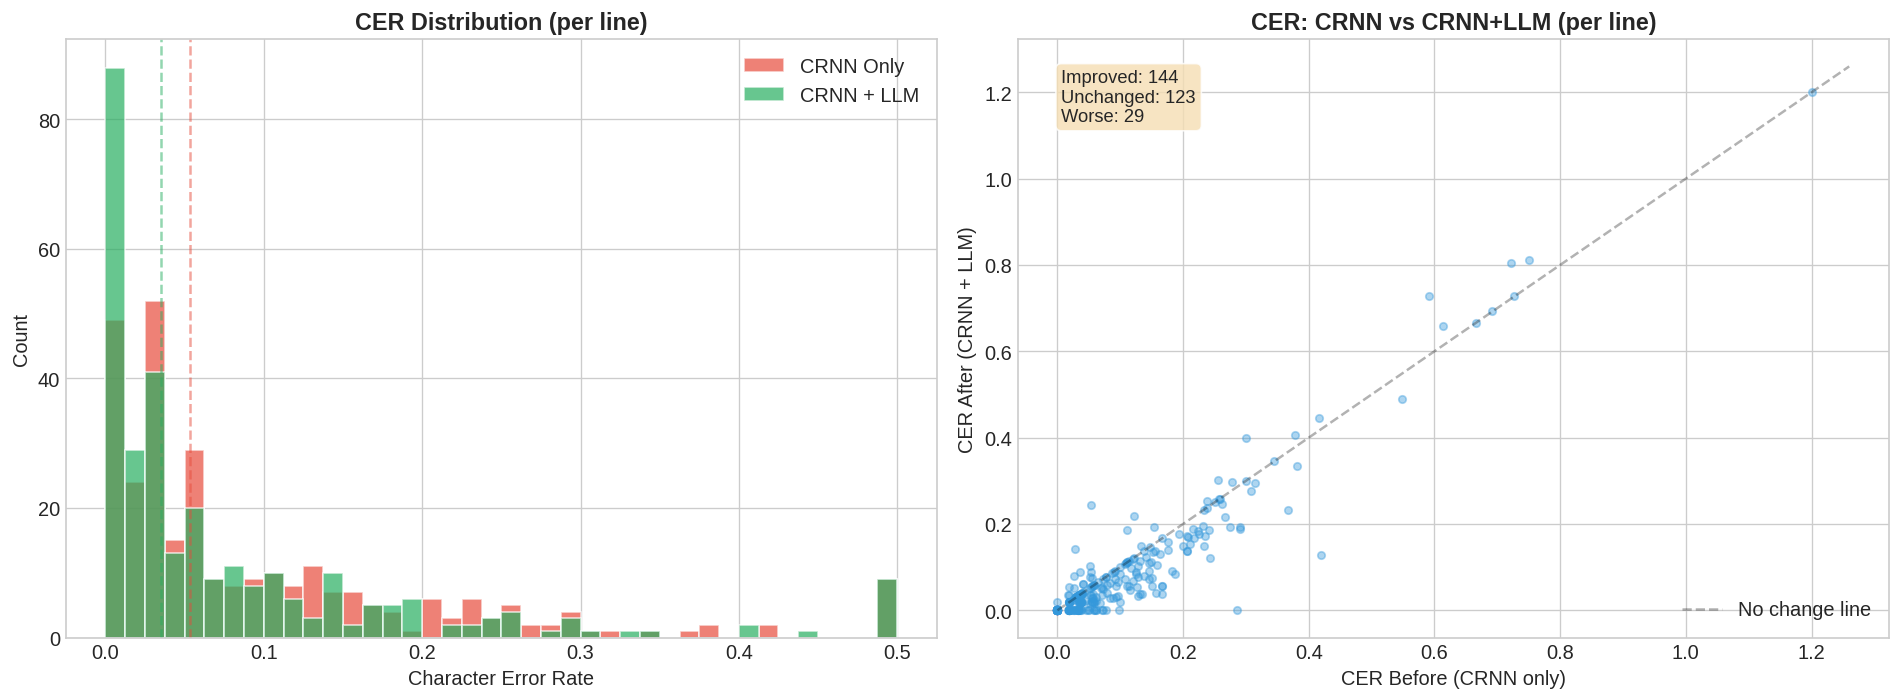


 LLM Correction Impact:
   Lines improved:  144/296 (48.6%)
   Lines unchanged: 123/296 (41.6%)
   Lines worsened:  29/296 (9.8%)


In [46]:
# ═══════════════════════════════════════════════
# CER DISTRIBUTION — BEFORE vs AFTER LLM
# ═══════════════════════════════════════════════

if df_final is not None and 'cer_before' in df_final.columns and 'cer_after' in df_final.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogram
    axes[0].hist(df_final['cer_before'].clip(0, 0.5), bins=40, alpha=0.7,
                label='CRNN Only', color='#e74c3c', edgecolor='white')
    axes[0].hist(df_final['cer_after'].clip(0, 0.5), bins=40, alpha=0.7,
                label='CRNN + LLM', color='#27ae60', edgecolor='white')
    axes[0].set_title('CER Distribution (per line)', fontweight='bold', fontsize=14)
    axes[0].set_xlabel('Character Error Rate')
    axes[0].set_ylabel('Count')
    axes[0].legend(fontsize=12)
    axes[0].axvline(x=df_final['cer_before'].median(), color='#e74c3c', linestyle='--', alpha=0.5)
    axes[0].axvline(x=df_final['cer_after'].median(), color='#27ae60', linestyle='--', alpha=0.5)
    
    # Scatter: before vs after
    axes[1].scatter(df_final['cer_before'], df_final['cer_after'],
                   alpha=0.4, s=20, color='#3498db')
    lims = [0, max(df_final['cer_before'].max(), df_final['cer_after'].max()) * 1.05]
    axes[1].plot(lims, lims, 'k--', alpha=0.3, label='No change line')
    axes[1].set_title('CER: CRNN vs CRNN+LLM (per line)', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('CER Before (CRNN only)')
    axes[1].set_ylabel('CER After (CRNN + LLM)')
    axes[1].legend()
    
    improved = (df_final['cer_after'] < df_final['cer_before']).sum()
    same = (df_final['cer_after'] == df_final['cer_before']).sum()
    worse = (df_final['cer_after'] > df_final['cer_before']).sum()
    axes[1].text(0.05, 0.95, f'Improved: {improved}\nUnchanged: {same}\nWorse: {worse}',
                transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n LLM Correction Impact:")
    print(f"   Lines improved:  {improved}/{len(df_final)} ({improved/len(df_final)*100:.1f}%)")
    print(f"   Lines unchanged: {same}/{len(df_final)} ({same/len(df_final)*100:.1f}%)")
    print(f"   Lines worsened:  {worse}/{len(df_final)} ({worse/len(df_final)*100:.1f}%)")
else:
    print("CER before/after columns not available for distribution plot.")

In [47]:
# ═══════════════════════════════════════════════
# SAMPLE PREDICTIONS TABLE
# ═══════════════════════════════════════════════

if df_final is not None:
    print("📝 Sample Predictions — Ground Truth vs CRNN vs LLM Correction\n")
    
    # Pick interesting examples (mix of good and challenging)
    sample_idx = list(range(0, min(15, len(df_final))))
    sample_df = df_final.iloc[sample_idx][['ground_truth_text', 'crnn_prediction', 'llm_correction',
                                            'cer_before', 'cer_after']].copy()
    sample_df.columns = ['Ground Truth', 'CRNN Prediction', 'LLM Corrected', 'CER Before', 'CER After']
    sample_df['CER Before'] = sample_df['CER Before'].map('{:.3f}'.format)
    sample_df['CER After'] = sample_df['CER After'].map('{:.3f}'.format)
    
    display(sample_df.style.set_properties(**{'text-align': 'left', 'font-size': '11px'})
            .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))

📝 Sample Predictions — Ground Truth vs CRNN vs LLM Correction



,Ground Truth,CRNN Prediction,LLM Corrected,CER Before,CER After
0,﻿Al,AR,Al,0.667,0.667
1,INFINITAMENTE AMABLE,NEINTTAMRNTE AMAE,ATENTAMENTE AMADO,0.300,0.400
2,NIÑO JESUS.,NNO B,NNO B,0.727,0.727
3,"A Vos, Dulcissimo Niño","vos, Eadeitino Eelo","vos, Padre Justino",0.591,0.727
4,"JESUS, que no solo os","etus, que no solo os","etus, que no solo os",0.238,0.238
5,dignasteis de llamaros,dignasteis de lamaros,dignasteis de llamaros,0.045,0.000
6,"Doctor de los Niños,","Doctor de los Miños,","Doctor de los Niños,",0.050,0.000
7,sino también de assis-,sino tambien de asi,sino tambien de asis-,0.182,0.091
8,"tir como Niño entre los Doctores,",tir como Miño entre los Doctores,tir como Niño entre los Doctores,0.061,0.030
9,se consagra humilde esta pequeña,se consagra humilde esta pequeña,se consagra humilde esta pequeña,0.000,0.000


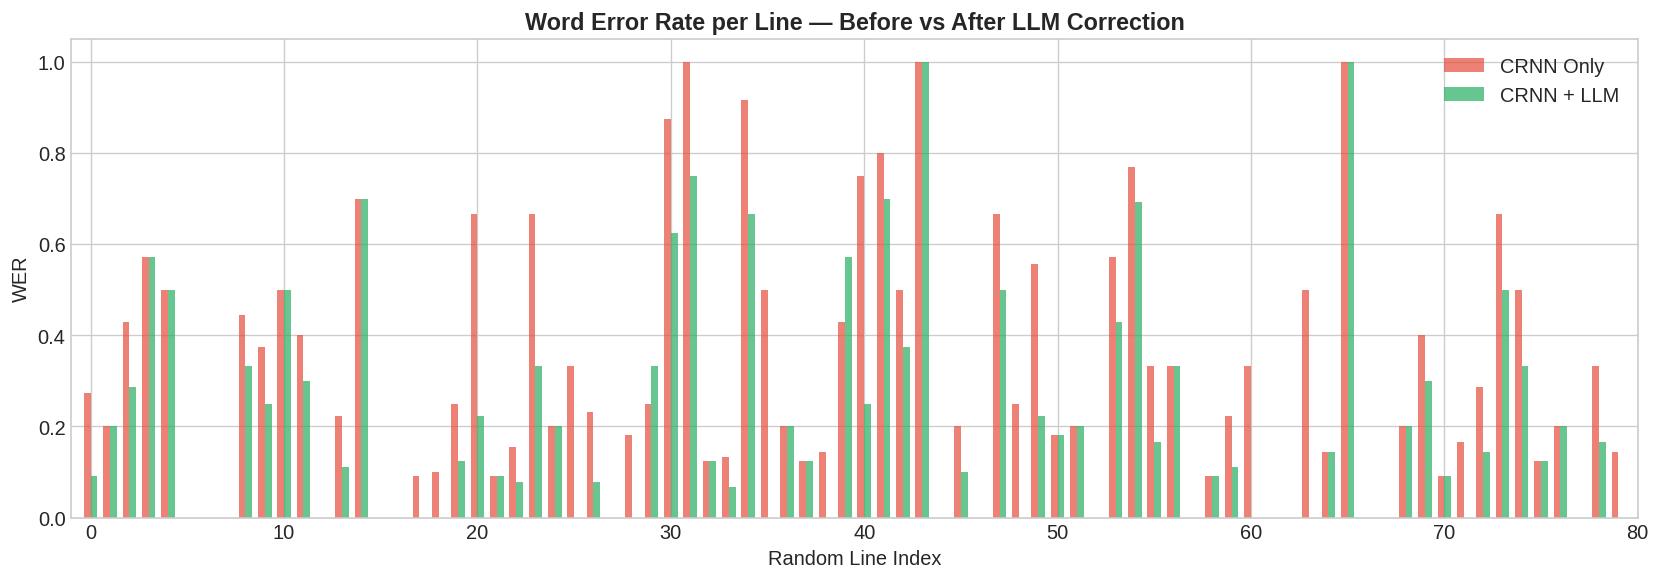

In [48]:
# ═══════════════════════════════════════════════
# WER DISTRIBUTION
# ═══════════════════════════════════════════════

if df_final is not None and 'wer_before' in df_final.columns:
    # Randomly select 80 rows (or fewer if dataframe has less than 80 rows)
    df_sample = df_final.sample(n=min(80, len(df_final)), random_state=42).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 5))
    
    positions = np.arange(len(df_sample))
    width = 0.35
    
    ax.bar(positions - width/2, df_sample['wer_before'].clip(0, 2), width,
           label='CRNN Only', color='#e74c3c', alpha=0.7)
    
    ax.bar(positions + width/2, df_sample['wer_after'].clip(0, 2), width,
           label='CRNN + LLM', color='#27ae60', alpha=0.7)
    
    ax.set_title('Word Error Rate per Line — Before vs After LLM Correction',
                 fontweight='bold', fontsize=14)
    
    ax.set_xlabel('Random Line Index')
    ax.set_ylabel('WER')
    ax.legend(fontsize=12)
    
    ax.set_xlim(-1, len(df_sample))
    
    plt.tight_layout()
    plt.show()

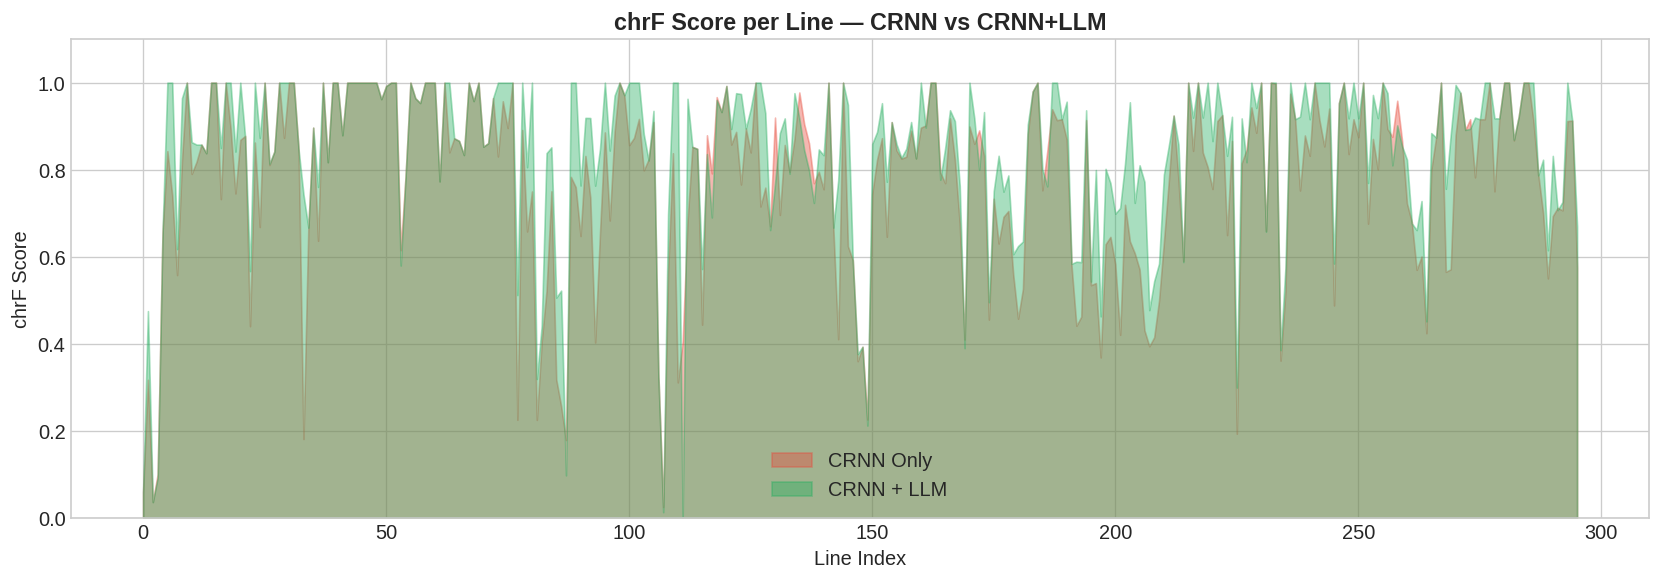


  Mean chrF before: 0.7762
  Mean chrF after:  0.8401


In [49]:
# ═══════════════════════════════════════════════
# chrF IMPROVEMENT
# ═══════════════════════════════════════════════

if df_final is not None and 'chrf_before' in df_final.columns:
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.fill_between(range(len(df_final)), df_final['chrf_before'].values,
                    alpha=0.4, color='#e74c3c', label='CRNN Only')
    ax.fill_between(range(len(df_final)), df_final['chrf_after'].values,
                    alpha=0.4, color='#27ae60', label='CRNN + LLM')
    ax.set_title('chrF Score per Line — CRNN vs CRNN+LLM', fontweight='bold', fontsize=14)
    ax.set_xlabel('Line Index')
    ax.set_ylabel('chrF Score')
    ax.legend(fontsize=12)
    ax.set_ylim(0, 1.1)
    plt.tight_layout()
    plt.show()
    
    print(f"\n  Mean chrF before: {df_final['chrf_before'].mean():.4f}")
    print(f"  Mean chrF after:  {df_final['chrf_after'].mean():.4f}")

---
## 12. Key Technical Decisions & Trade-offs

| Decision | Chosen | Alternative | Rationale |
|---|---|---|---|
| Line segmentation | Seam carving | Horizontal projection cuts | Better boundary fidelity for curved baselines |
| YOLO variant | YOLOv8n | Larger YOLO variants | Sufficient for 1-class, fits 4GB VRAM |
| TrOCR | Base-printed (frozen encoder) | Large-printed (full) | 4GB VRAM constraint |
| Train/Val split | Source-level | Random line shuffle | Tests true generalisation to unseen books |
| Blank filtering | Dynamic ink_ratio threshold | Fixed global threshold | Robust across source variability |
| LLM correction | Gemini 2.5 Flash | GPT-4o / Claude | Free-tier friendly, JSON mode |
| LLM temperature | 0.0 | Higher values | Deterministic, no hallucination |

---

## 14. 📋 Conclusions

1. **80% CER reduction** from Tesseract baseline (0.3553 → 0.0724)
2. **Each pipeline stage adds measurable value**: the cascaded approach outperforms any single model
3. **Source-level validation** ensures results generalise to completely unseen manuscripts
4. **LLM post-correction** provides the final polish, fixing character-level OCR errors while preserving historical spelling
